In [2]:
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

In [3]:
# === Conexion Athena estilo Cruce + fallback awswrangler ===
import os
import re
import sys
from pathlib import Path

import boto3
import awswrangler as wr
import pandas as pd

EXPLICIT_CREDENTIALS_SH = Path(r"c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test/credentials.sh")


def _find_dir_with_athena_client(preferred_dir: Path | None = None) -> Path | None:
    cwd = Path.cwd().resolve()
    search_roots = []

    if preferred_dir is not None:
        search_roots.append(preferred_dir)

    search_roots.extend([cwd, *cwd.parents])

    home = Path.home()
    search_roots.extend([
        home / "OneDrive - Interbank" / "conexion_aws" / "athena_conection_test",
        Path("c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test"),
    ])

    visited = set()
    for root in search_roots:
        if root in visited:
            continue
        visited.add(root)

        if not root.exists():
            continue
        if (root / "athena_client.py").exists() and (root / "athena_config.json").exists():
            return root
    return None


def _load_credentials_from_sh(sh_path: Path) -> list[str]:
    if not sh_path.exists():
        return []

    loaded_keys: list[str] = []
    pattern = re.compile(r'^\s*export\s+([A-Za-z_][A-Za-z0-9_]*)=(.*)$')

    for line in sh_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = pattern.match(line)
        if not match:
            continue

        key, raw_val = match.groups()
        value = raw_val.strip().strip('"').strip("'")
        if key and value:
            os.environ[key] = value
            loaded_keys.append(key)

    return loaded_keys


def _build_session(aws_region: str) -> boto3.Session:
    aws_profile = os.getenv("AWS_PROFILE")
    if aws_profile:
        return boto3.Session(profile_name=aws_profile, region_name=aws_region)
    return boto3.Session(region_name=aws_region)


def _session_is_valid(sess: boto3.Session) -> tuple[bool, str | None]:
    try:
        sts = sess.client("sts")
        _ = sts.get_caller_identity()
        return True, None
    except Exception as exc:
        return False, str(exc)


ATHENA_MODE = "wrangler"
ATHENA_DATABASE = os.getenv("ATHENA_DATABASE", "disc_comercial")
ATHENA_WORKGROUP = os.getenv("ATHENA_WORKGROUP", "primary")
ATHENA_OUTPUT = os.getenv(
    "ATHENA_OUTPUT",
    "s3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/athena_results/"
 )
AWS_REGION = os.getenv("AWS_REGION", "us-east-1")

client = None

credentials_file = EXPLICIT_CREDENTIALS_SH if EXPLICIT_CREDENTIALS_SH.exists() else None
if credentials_file is None:
    print(f"⚠ No se encontró credentials.sh en ruta fija: {EXPLICIT_CREDENTIALS_SH}")

preferred_dir = credentials_file.parent if credentials_file is not None else None
athena_dir = _find_dir_with_athena_client(preferred_dir=preferred_dir)
loaded_cred_keys: list[str] = []

if credentials_file is not None:
    loaded_cred_keys = _load_credentials_from_sh(credentials_file)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {credentials_file}")
elif athena_dir is not None:
    fallback_sh = athena_dir / "credentials.sh"
    loaded_cred_keys = _load_credentials_from_sh(fallback_sh)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {fallback_sh}")

try:
    session = _build_session(AWS_REGION)
except Exception:
    session = boto3.Session(region_name=AWS_REGION)

ok_session, session_error = _session_is_valid(session)
if not ok_session and session_error and "ExpiredToken" in session_error and loaded_cred_keys:
    print("⚠ Se detectó token expirado en credentials.sh. Reintentando con credenciales locales (perfil/default)...")
    for key in ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_SESSION_TOKEN"]:
        os.environ.pop(key, None)
    session = _build_session(AWS_REGION)

if athena_dir is not None:
    if str(athena_dir) not in sys.path:
        sys.path.append(str(athena_dir))
    try:
        from athena_client import AthenaClient

        if credentials_file is None:
            credentials_file = athena_dir / "credentials.sh"

        client = AthenaClient(
            credentials_file=str(credentials_file),
            config_file=str(athena_dir / "athena_config.json"),
        )
        ATHENA_MODE = "athena_client"
        print(f"✓ AthenaClient cargado desde: {athena_dir}")
    except Exception as exc:
        print(f"⚠ No se pudo inicializar AthenaClient ({exc}). Se usará awswrangler.")
else:
    print("⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.")


def athena_query(query: str, database: str = ATHENA_DATABASE) -> pd.DataFrame:
    if ATHENA_MODE == "athena_client" and client is not None:
        return client.query(query)
    return wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False,
        boto3_session=session,
        workgroup=ATHENA_WORKGROUP,
        s3_output=ATHENA_OUTPUT,
    )


def s3_read_csv(path: str, sep: str = "|", **kwargs) -> pd.DataFrame:
    return wr.s3.read_csv(path=path, sep=sep, boto3_session=session, **kwargs)


def test_aws_connection(sample_s3_path: str | None = None) -> None:
    sts = session.client("sts")
    ident = sts.get_caller_identity()
    print(f"✓ AWS Account: {ident.get('Account')} | ARN: {ident.get('Arn')}")

    if sample_s3_path:
        _ = wr.s3.read_csv(path=sample_s3_path, sep='|', boto3_session=session, nrows=1)
        print(f"✓ Lectura S3 OK: {sample_s3_path}")


print(f"Modo Athena activo: {ATHENA_MODE}")
print(f"DB: {ATHENA_DATABASE} | WG: {ATHENA_WORKGROUP}")
print(f"credentials.sh en uso: {credentials_file}")
print("Helper Athena: athena_query(query)")
print("Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')")
print("Diagnóstico opcional: test_aws_connection()")

✓ Credenciales cargadas desde: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.
Modo Athena activo: wrangler
DB: disc_comercial | WG: primary
credentials.sh en uso: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
Helper Athena: athena_query(query)
Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')
Diagnóstico opcional: test_aws_connection()


In [4]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [5]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from numpy import loadtxt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
import pylab as pl

from collections import Counter
from sklearn.datasets import make_classification

In [6]:
# Función para comprimir datos #######################################################
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [7]:
import numpy as np

In [8]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

# MODELOS

In [8]:
from sagemaker.tuner import HyperparameterTuner
#Solo variables importantes
nombre_exportado = HyperparameterTuner.attach('hpo-plaft-pj-minoris-260803-2126').best_training_job()
print(nombre_exportado)

ModuleNotFoundError: No module named 'sagemaker'

In [9]:
#!pip install xgboost --prefer-binary

In [10]:
!pip install --force-reinstall "xgboost==1.7.6"

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.65.1 requires numpy<2.5,>=1.22, but you have numpy 2.5.2 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [11]:
import xgboost as xgb

print(xgb.__version__)

1.7.6


In [12]:
import boto3
import tarfile
import xgboost as xgb
import os

# Parámetros
# Parámetros
bucket_name = 'ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'
nombre_exportado = 'hpo-plaft-pj-minoris-260803-2126-022-10aa0dbf'

# Descargar model.tar.gz desde S3
s3 = boto3.client('s3')

with open('model.tar.gz', 'wb') as f:
    s3.download_fileobj(
        bucket_name,
        f'{model_prefix}/MODEL/output/{nombre_exportado}/output/model.tar.gz',
        f
    )

# Extraer el archivo tar.gz
with tarfile.open('model.tar.gz', 'r:gz') as tar:
    tar.extractall(path='model')

# Cargar el modelo con XGBoost
model_path = os.path.join('model', 'xgboost-model')
model = xgb.Booster()
model.load_model(model_path)

# ¡Listo! Ya podés usar model.predict(...) con DMatrix


C:\Users\b46637\AppData\Local\Temp\ipykernel_11448\2417049600.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='model')


In [13]:
import pandas as pd

import pandas as pd

# ===============================================================
# 1. Parámetros de tu bucket y prefijo
# ===============================================================
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

# Ejemplo completo:
# bucket_name  = "sagemaker-us-east-1-123456789012"
# model_prefix = "risk-fraud-model/2025-12-05"

# ===============================================================
# 2. Rutas en S3
# ===============================================================
base_s3_path = f"s3://{bucket_name}/{model_prefix}/data_dev_model"

headers_path      = f"{base_s3_path}/headers_total.csv"
train_path        = f"{base_s3_path}/train_total.csv"
val_path          = f"{base_s3_path}/validation_total.csv"
test_path         = f"{base_s3_path}/test_total.csv"
extras_val_path   = f"{base_s3_path}/extras_validation_total.csv"
extras_test_path  = f"{base_s3_path}/extras_test_total.csv"

# ===============================================================
# 3. Cargar headers (orden y tipos)
# ===============================================================
headers = pd.read_csv(headers_path)
column_order = headers['variables'].tolist()

print(f"Se cargaron {len(column_order)} variables desde S3")
print("Primeras 10 variables:", column_order[:10])

# ===============================================================
# 4. Cargar train / val / test SIN header, pero CON nombres correctos
# ===============================================================
df_train = pd.read_csv(train_path, header=None, names=column_order)
df_val   = pd.read_csv(val_path,   header=None, names=column_order)
df_test  = pd.read_csv(test_path,  header=None, names=column_order)

print(f"\nShapes cargados desde S3:")
print(f"  Train : {df_train.shape}")
print(f"  Val   : {df_val.shape}")
print(f"  Test  : {df_test.shape}")

# ===============================================================
# 5. Cargar extras (num_documento, mes_base, tipo_alerta_n2)
# ===============================================================
extras_val  = pd.read_csv(extras_val_path)
extras_test = pd.read_csv(extras_test_path)

# Pegamos las columnas de reporting al dataframe original
df_val  = pd.concat([df_val.reset_index(drop=True), 
                     extras_val[['key_value','cod_cli' ,'cod_mes','tipo_alerta_n2','trx_riesgo_cliente']]], axis=1)

df_test = pd.concat([df_test.reset_index(drop=True), 
                     extras_test[['key_value','cod_cli' , 'cod_mes','tipo_alerta_n2','trx_riesgo_cliente']]], axis=1)

# ===============================================================
# 6. Verificación final
# ===============================================================
print("\nListo! Todo cargado correctamente desde S3")
print(f"df_val  ahora tiene {df_val.shape[1]} columnas (incluye num_documento y mes_base)")
print(f"df_test ahora tiene {df_test.shape[1]} columnas")

# Ejemplo rápido de uso
display(df_val[['key_value', 'cod_cli' ,'cod_mes', 'target','tipo_alerta_n2','trx_riesgo_cliente']].head())

Se cargaron 33 variables desde S3
Primeras 10 variables: ['target', 'cnt_trx_cargostot_3m', 'mto_pas_soles', 'rat_pastot_x_ingtot_6m', 'cnt_trx_abonospromtot_3m', 'imp_trx_abonosefect_6m', 'num_antiguedad', 'imp_trx_cargosefe_6m', 'ratio_cargos_1m_vs_6m', 'cnt_meses_sinegresos_12m']

Shapes cargados desde S3:
  Train : (173600, 33)
  Val   : (324253, 33)
  Test  : (1509824, 33)

Listo! Todo cargado correctamente desde S3
df_val  ahora tiene 38 columnas (incluye num_documento y mes_base)
df_test ahora tiene 38 columnas


,key_value,cod_cli,cod_mes,target,tipo_alerta_n2,trx_riesgo_cliente
0,3B020DB4DC631ED9192290632AD8627B2A9495500B2783...,21602930.0,202508.0,0.0,SIN_INFO,SIN_INFO
1,2820FF155EBE1FF50F339495F0BDE21578CCE6AFD934D9...,7321045.0,202508.0,0.0,SIN_INFO,SIN_INFO
2,3194E86A626832BA5994B2318E2D0A0774892E5D769D76...,19639492.0,202508.0,0.0,SIN_INFO,SIN_INFO
3,566A75C788AB628F0A7BAE537CBBBD49F613E1FEAA85A4...,21010838.0,202509.0,0.0,SIN_INFO,SIN_INFO
4,6A5C84509F82D207D3F611E0FBBBA19AA144C80E686E3E...,18466306.0,202509.0,0.0,SIN_INFO,SIN_INFO


In [12]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [13]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 !='SIN_INFO')]

In [14]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_test_3 = df_test.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cod_cli', 'cod_mes', 'tipo_alerta_n2','trx_riesgo_cliente']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [15]:
df_test_3['prob'] = model.predict(dtest)

In [16]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_test_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202508.0    0.950945
202509.0    0.944097
202510.0    0.898831
202511.0    0.927584
202512.0    0.902826
202601.0    0.963558
202602.0    0.940175
202603.0    0.918342
202604.0    0.967561
dtype: float64


C:\Users\b46637\AppData\Local\Temp\ipykernel_11448\29427415.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_test_3.groupby('cod_mes').apply(


In [17]:
gini_promedio = gini_por_mes.mean()

print(f"\nGini promedio de todos los meses: {gini_promedio:.4f}")



Gini promedio de todos los meses: 0.9349


In [18]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# -------------------------------------------------
# Configuración
# -------------------------------------------------
MES = 202508
THRESHOLD = 0.99296  # tu umbral definido
cols_excluir = ['key_value', 'cod_cli' ,'cod_mes', 'cod_cli' , 'tipo_alerta_n2', 'target','trx_riesgo_cliente']

# -------------------------------------------------
# Filtrar datos del mes
# -------------------------------------------------
test_data = df_test[df_test.cod_mes == float(MES)].copy()

if test_data.empty:
    print(f"⚠️ No hay datos para el mes {MES}")
else:
    # Preparar X_test
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    # Predicciones
    test_data['prob'] = model.predict(dtest)

    # Verdaderos / predichos
    y_true = test_data['target'].values
    y_score = test_data['prob'].values
    y_pred = (y_score >= THRESHOLD).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n=== Matriz de Confusión Mes {MES} ===")
    print(pd.DataFrame(
        cm,
        index=["Real 0", "Real 1"],
        columns=["Pred 0", "Pred 1"]
    ))
    print(f"\nTP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")
    print(f"Precision: {tp / (tp + fp):.4f}")
    print(f"Recall:    {tp / (tp + fn):.4f}")



=== Matriz de Confusión Mes 202508 ===
        Pred 0  Pred 1
Real 0  161080     217
Real 1      91      27

TP: 27 | FP: 217 | FN: 91 | TN: 161080
Precision: 0.1107
Recall:    0.2288


In [19]:
#validation

In [20]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_val_3 = df_val.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cod_cli', 'cod_mes', 'tipo_alerta_n2','trx_riesgo_cliente']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_val_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [21]:
df_val_3['prob'] = model.predict(dtest)

In [22]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_val_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)

Gini por mes:
cod_mes
202508.0    0.950945
202509.0    0.944097
dtype: float64


C:\Users\b46637\AppData\Local\Temp\ipykernel_11448\1839909994.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_val_3.groupby('cod_mes').apply(


In [23]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [24]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')]

In [25]:
meses = [202508, 202509, 202510, 202511, 202512,202601,202602,202603,202604]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_cli' ,'cod_mes',  'cod_cli' ,'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=5
    )

In [26]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000787, 0.0239]",32283,0,0.000000,0.200146,1.000000,32283,118
"(0.0239, 0.08]",32282,1,0.000031,0.400286,1.000000,64565,118
"(0.08, 0.142]",32282,1,0.000031,0.600427,0.991525,96847,117
"(0.142, 0.278]",32290,0,0.000000,0.800616,0.983051,129137,116
"(0.278, 0.998]",32160,116,0.003594,1.000000,0.983051,161297,116


In [27]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000322, 0.0244]",32568,0,0.000000,0.200124,1.000000,32568,99
"(0.0244, 0.0807]",32567,0,0.000000,0.400242,1.000000,65135,99
"(0.0807, 0.143]",32568,0,0.000000,0.600366,1.000000,97703,99
"(0.143, 0.279]",32564,3,0.000092,0.800466,1.000000,130267,99
"(0.279, 0.998]",32472,96,0.002948,1.000000,0.969697,162739,96


In [28]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000715, 0.025]",32955,0,0.000000,0.200153,1.000,32955,125
"(0.025, 0.082]",32954,1,0.000030,0.400300,1.000,65909,125
"(0.082, 0.144]",32951,3,0.000091,0.600429,0.992,98860,124
"(0.144, 0.283]",32974,6,0.000182,0.800697,0.968,131834,121
"(0.283, 0.999]",32815,115,0.003492,1.000000,0.920,164649,115


In [29]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000724, 0.0259]",33264,0,0.000000,0.200079,1.000000,33264,63
"(0.0259, 0.0836]",33263,0,0.000000,0.400153,1.000000,66527,63
"(0.0836, 0.148]",33262,1,0.000030,0.600220,1.000000,99789,63
"(0.148, 0.288]",33262,1,0.000030,0.800288,0.984127,133051,62
"(0.288, 0.999]",33203,61,0.001834,1.000000,0.968254,166254,61


In [30]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000693, 0.0261]",34267,0,0.000000,0.200023,1.0000,34267,16
"(0.0261, 0.0828]",34266,0,0.000000,0.400041,1.0000,68533,16
"(0.0828, 0.145]",34265,1,0.000029,0.600053,1.0000,102798,16
"(0.145, 0.284]",34266,0,0.000000,0.800070,0.9375,137064,15
"(0.284, 0.999]",34251,15,0.000438,1.000000,0.9375,171315,15


In [31]:
tablas_quintiles[202603]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000804, 0.029]",34086,0,0.000000,0.200151,1.000,34086,125
"(0.029, 0.0845]",34085,0,0.000000,0.400297,1.000,68171,125
"(0.0845, 0.148]",34080,5,0.000147,0.600413,1.000,102251,125
"(0.148, 0.293]",34084,1,0.000029,0.800553,0.960,136335,120
"(0.293, 0.999]",33966,119,0.003491,1.000000,0.952,170301,119


In [35]:
tablas_quintiles[202604]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000876, 0.0296]",34555,0,0.000000,0.200585,1.000000,34555,234
"(0.0296, 0.0852]",34447,0,0.000000,0.400543,1.000000,69002,234
"(0.0852, 0.15]",34500,1,0.000029,0.600809,1.000000,103502,234
"(0.15, 0.296]",34500,1,0.000029,0.801075,0.995726,138002,233
"(0.296, 0.999]",34269,232,0.006724,1.000000,0.991453,172271,232


In [36]:
df_test_2= df_test[(df_test.cod_mes ==202604)]

In [37]:
#solo alarmas 

In [38]:
df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [39]:
meses = [202508, 202509, 202510, 202511, 202512,202601,202602,202603,202604]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test_1[df_test_1.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_cli' ,'cod_mes',  'cod_cli' ,'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=5
    )

In [40]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00263, 0.224]",39,0,0.000000,0.245283,1.000000,39,34
"(0.224, 0.69]",34,4,0.105263,0.459119,1.000000,73,34
"(0.69, 0.892]",34,5,0.128205,0.672956,0.882353,107,30
"(0.892, 0.977]",28,10,0.263158,0.849057,0.735294,135,25
"(0.977, 0.997]",24,15,0.384615,1.000000,0.441176,159,15


In [41]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00208, 0.392]",55,0,0.000000,0.215686,1.000000,55,17
"(0.392, 0.815]",53,1,0.018519,0.423529,1.000000,108,17
"(0.815, 0.932]",53,1,0.018519,0.631373,0.941176,161,16
"(0.932, 0.977]",51,3,0.055556,0.831373,0.882353,212,15
"(0.977, 0.998]",43,12,0.218182,1.000000,0.705882,255,12


In [42]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.014100000000000001, 0.24]",53,0,0.000000,0.226496,1.000000,53,30
"(0.24, 0.734]",53,0,0.000000,0.452991,1.000000,106,30
"(0.734, 0.905]",48,4,0.076923,0.658120,1.000000,154,30
"(0.905, 0.979]",47,6,0.113208,0.858974,0.866667,201,26
"(0.979, 0.999]",33,20,0.377358,1.000000,0.666667,234,20


In [43]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0070999999999999995, 0.246]",36,0,0.000000,0.229299,1.000000,36,19
"(0.246, 0.753]",32,3,0.085714,0.433121,1.000000,68,19
"(0.753, 0.905]",32,3,0.085714,0.636943,0.842105,100,16
"(0.905, 0.971]",31,4,0.114286,0.834395,0.684211,131,13
"(0.971, 0.997]",26,9,0.257143,1.000000,0.473684,157,9


In [44]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00502, 0.155]",57,0,0.000000,0.202847,1.0,57,2
"(0.155, 0.582]",56,0,0.000000,0.402135,1.0,113,2
"(0.582, 0.851]",57,0,0.000000,0.604982,1.0,170,2
"(0.851, 0.939]",56,0,0.000000,0.804270,1.0,226,2
"(0.939, 0.997]",55,2,0.035088,1.000000,1.0,281,2


In [45]:
tablas_quintiles[202601]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0019199999999999998, 0.246]",26,0,0.00,0.254902,1.000000,26,24
"(0.246, 0.858]",21,4,0.16,0.460784,1.000000,47,24
"(0.858, 0.956]",22,3,0.12,0.676471,0.833333,69,20
"(0.956, 0.983]",20,5,0.20,0.872549,0.708333,89,17
"(0.983, 0.997]",13,12,0.48,1.000000,0.500000,102,12


In [46]:
tablas_quintiles[202602]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.00025600000000000004, 0.193]",105,0,0.000000,0.204678,1.000000,105,11
"(0.193, 0.644]",105,0,0.000000,0.409357,1.000000,210,11
"(0.644, 0.871]",103,1,0.009615,0.610136,1.000000,313,11
"(0.871, 0.955]",103,2,0.019048,0.810916,0.909091,416,10
"(0.955, 0.999]",97,8,0.076190,1.000000,0.727273,513,8


In [47]:
tablas_quintiles[202603]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000717, 0.153]",24,0,0.000000,0.214286,1.000,24,8
"(0.153, 0.658]",24,0,0.000000,0.428571,1.000,48,8
"(0.658, 0.897]",23,1,0.041667,0.633929,1.000,71,8
"(0.897, 0.961]",19,5,0.208333,0.803571,0.875,90,7
"(0.961, 0.998]",22,2,0.083333,1.000000,0.250,112,2


In [48]:
tablas_quintiles[202604]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00586, 0.799]",54,5,0.084746,0.293478,1.000000,54,110
"(0.799, 0.926]",45,14,0.237288,0.538043,0.954545,99,105
"(0.926, 0.969]",35,23,0.396552,0.728261,0.827273,134,91
"(0.969, 0.985]",29,30,0.508475,0.885870,0.618182,163,68
"(0.985, 0.998]",21,38,0.644068,1.000000,0.345455,184,38


In [49]:
#from pathlib import Path
#output_path = Path(r"/PLAFT/Desarrollo/Desarrollo/PJ/MINORISTA/Artefactos/Inferencia/alertas_ordenadas_automaticas_sinriegoalto.csv")
#df_test_2.to_csv(output_path, index=False, encoding="utf-8-sig")
#print(f"✓ CSV exportado: {output_path} | Filas: {len(df_test_2):,}")

In [50]:
meses = [202508, 202509, 202510, 202511,202512]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_mes', 'cod_cli' , 'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=1000
    )


In [51]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0001134, 0.001799]",162,0,0.000000,0.001004,1.000000,162,118
"(0.001799, 0.002104]",161,0,0.000000,0.002003,1.000000,323,118
"(0.002104, 0.00231]",162,0,0.000000,0.003007,1.000000,485,118
"(0.00231, 0.0025]",161,0,0.000000,0.004005,1.000000,646,118
"(0.0025, 0.002665]",162,0,0.000000,0.005009,1.000000,808,118
...,...,...,...,...,...,...,...
"(0.9824, 0.9859]",155,7,0.043210,0.996262,0.423729,160694,50
"(0.9859, 0.9891]",155,6,0.037267,0.997223,0.364407,160849,43
"(0.9891, 0.9915]",158,4,0.024691,0.998202,0.313559,161007,37


In [52]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00066803, 0.0017963]",163,0,0.000000,0.001002,1.000000,163,99
"(0.0017963, 0.0021272]",163,0,0.000000,0.002003,1.000000,326,99
"(0.0021272, 0.0023114]",163,0,0.000000,0.003005,1.000000,489,99
"(0.0023114, 0.0025096]",163,0,0.000000,0.004006,1.000000,652,99
"(0.0025096, 0.0026912]",163,0,0.000000,0.005008,1.000000,815,99
...,...,...,...,...,...,...,...
"(0.98266, 0.98605]",157,6,0.036810,0.996178,0.363636,162117,36
"(0.98605, 0.9889]",159,4,0.024540,0.997155,0.303030,162276,30
"(0.9889, 0.99194]",156,7,0.042945,0.998114,0.262626,162432,26


In [53]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0001848, 0.001803]",165,0,0.000000,0.001002,1.000,165,125
"(0.001803, 0.002128]",185,0,0.000000,0.002126,1.000,350,125
"(0.002128, 0.002322]",145,0,0.000000,0.003006,1.000,495,125
"(0.002322, 0.002509]",165,0,0.000000,0.004009,1.000,660,125
"(0.002509, 0.002706]",164,0,0.000000,0.005005,1.000,824,125
...,...,...,...,...,...,...,...
"(0.9823, 0.9865]",161,3,0.018293,0.996283,0.408,164037,51
"(0.9865, 0.9892]",158,7,0.042424,0.997243,0.384,164195,48
"(0.9892, 0.9922]",159,6,0.036364,0.998208,0.328,164354,41


In [54]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00027484499999999996, 0.0018404]",167,0,0.000000,0.001004,1.000000,167,63
"(0.0018404, 0.00212757]",176,0,0.000000,0.002063,1.000000,343,63
"(0.00212757, 0.00233758]",156,0,0.000000,0.003001,1.000000,499,63
"(0.00233758, 0.00254109]",167,0,0.000000,0.004006,1.000000,666,63
"(0.00254109, 0.00269707]",166,0,0.000000,0.005004,1.000000,832,63
...,...,...,...,...,...,...,...
"(0.983804, 0.986936]",165,1,0.006024,0.996096,0.285714,165605,18
"(0.986936, 0.989622]",164,3,0.017964,0.997083,0.269841,165769,17
"(0.989622, 0.992577]",162,4,0.024096,0.998057,0.222222,165931,14


In [55]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.000306404, 0.0018335]",172,0,0.000000,0.001004,1.0000,172,16
"(0.0018335, 0.00212757]",175,0,0.000000,0.002026,1.0000,347,16
"(0.00212757, 0.00235251]",167,0,0.000000,0.003000,1.0000,514,16
"(0.00235251, 0.0025563]",172,0,0.000000,0.004004,1.0000,686,16
"(0.0025563, 0.00275162]",178,0,0.000000,0.005043,1.0000,864,16
...,...,...,...,...,...,...,...
"(0.983961, 0.987089]",171,0,0.000000,0.996013,0.1875,170632,3
"(0.987089, 0.990061]",172,0,0.000000,0.997017,0.1875,170804,3
"(0.990061, 0.992578]",170,1,0.005848,0.998010,0.1875,170974,3


In [56]:
import pandas as pd
import numpy as np

def metricas_top_k(df, target_col, score_col, k_list):
    """
    Calcula Recall@K y Precision@K para distintos valores de K
    """
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    total_positivos = df[target_col].sum()

    resultados = []

    for k in k_list:
        top_k = df.head(k)
        tp_k = top_k[target_col].sum()

        recall_k = tp_k / total_positivos if total_positivos > 0 else 0
        precision_k = tp_k / k if k > 0 else 0

        resultados.append({
            "K": k,
            "score_min": top_k[score_col].min(),
            "TP": tp_k,
            "Recall": recall_k,
            "Precision": precision_k
        })

    return pd.DataFrame(resultados)


In [57]:
meses = [202508, 202509, 202510, 202511, 202512,202604]
k_list = [100, 200, 500, 1000, 2000]

resultados_meses = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    cols_excluir = ['key_value', 'cod_mes',  'cod_cli' ,'tipo_alerta_n2', 'target','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')

    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    test_data['prob'] = model.predict(dtest)

    # Solo alertas nuevas
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    tabla_k = metricas_top_k(
        test_data_alerta,
        target_col="target",
        score_col="prob",
        k_list=k_list
    )

    tabla_k["mes"] = mes
    resultados_meses[mes] = tabla_k


In [58]:
df_metricas = pd.concat(
    resultados_meses.values(),
    ignore_index=True
)

df_metricas


,K,score_min,TP,Recall,Precision,mes
0,100,0.995190,16.0,0.135593,0.1600,202508
1,200,0.993580,26.0,0.220339,0.1300,202508
2,500,0.988720,37.0,0.313559,0.0740,202508
3,1000,0.977754,60.0,0.508475,0.0600,202508
4,2000,0.951468,80.0,0.677966,0.0400,202508
5,100,0.995521,7.0,0.070707,0.0700,202509
6,200,0.993716,15.0,0.151515,0.0750,202509
7,500,0.988662,26.0,0.262626,0.0520,202509
8,1000,0.978254,41.0,0.414141,0.0410,202509
9,2000,0.951332,57.0,0.575758,0.0285,202509


In [59]:
def optimal_threshold_topk(
    df,
    score_col="prob",
    target_col="target",
    k=1000,
    n_groups=5
):
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # Total positivos reales (para recall)
    total_positivos = (df[target_col] == 1).sum()

    # Nos quedamos solo con los top K
    df_topk = df.iloc[:k].copy()

    group_size = k // n_groups
    resultados = []

    acumulado = pd.DataFrame()

    for g in range(1, n_groups + 1):
        inicio = (g - 1) * group_size
        fin = g * group_size

        acumulado = df_topk.iloc[:fin]

        tp = (acumulado[target_col] == 1).sum()
        fp = fin - tp
        fn = total_positivos - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0
        )

        threshold = acumulado[score_col].min()

        resultados.append({
            "grupo": g,
            "casos_hasta": fin,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(resultados)


In [60]:
resultados_mes = {}

for mes in meses:
    df_mes = df_test[df_test.cod_mes == mes].copy()
    df_mes = df_mes[df_mes.tipo_alerta_n2 != 0]

    if df_mes.empty:
        continue

    X = df_mes.drop(
        columns=["key_value", "cod_mes", 'cod_cli' , "tipo_alerta_n2", "target","trx_riesgo_cliente"],
        errors="ignore"
    )

    dtest = xgb.DMatrix(X)
    df_mes["prob"] = model.predict(dtest)

    tabla = optimal_threshold_topk(
        df_mes,
        score_col="prob",
        target_col="target",
        k=1000,
        n_groups=5
    )

    resultados_mes[mes] = tabla



In [61]:
for mes, tabla in resultados_mes.items():
    print(f"\nMes {mes}")
    display(tabla.sort_values("f1", ascending=False).head(1))



Mes 202508


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.99358,0.13,0.220339,0.163522



Mes 202509


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.993716,0.075,0.151515,0.100334



Mes 202510


...

,grupo,casos_hasta,threshold,precision,recall,f1
1,2,400,0.991373,0.0275,0.174603,0.047516



Mes 202512


,grupo,casos_hasta,threshold,precision,recall,f1
4,5,1000,0.98131,0.005,0.3125,0.009843



Mes 202604


,grupo,casos_hasta,threshold,precision,recall,f1
2,3,600,0.989226,0.118333,0.303419,0.170264


In [62]:
df_optimos = []

for mes, tabla in resultados_mes.items():
    best = tabla.sort_values("f1", ascending=False).iloc[0]
    best["mes"] = mes
    df_optimos.append(best)

df_optimos = pd.DataFrame(df_optimos)
df_optimos


,grupo,casos_hasta,threshold,precision,recall,f1,mes
0,1.0,200.0,0.993580,0.130000,0.220339,0.163522,202508.0
0,1.0,200.0,0.993716,0.075000,0.151515,0.100334,202509.0
0,1.0,200.0,0.994050,0.125000,0.200000,0.153846,202510.0
1,2.0,400.0,0.991373,0.027500,0.174603,0.047516,202511.0
4,5.0,1000.0,0.981310,0.005000,0.312500,0.009843,202512.0
2,3.0,600.0,0.989226,0.118333,0.303419,0.170264,202604.0


In [63]:
threshold_final = df_optimos["threshold"].quantile(0.25)
threshold_final


np.float64(0.989762544631958)

In [64]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 125.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 126.3 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [shap]3/4 [shap]]te]


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


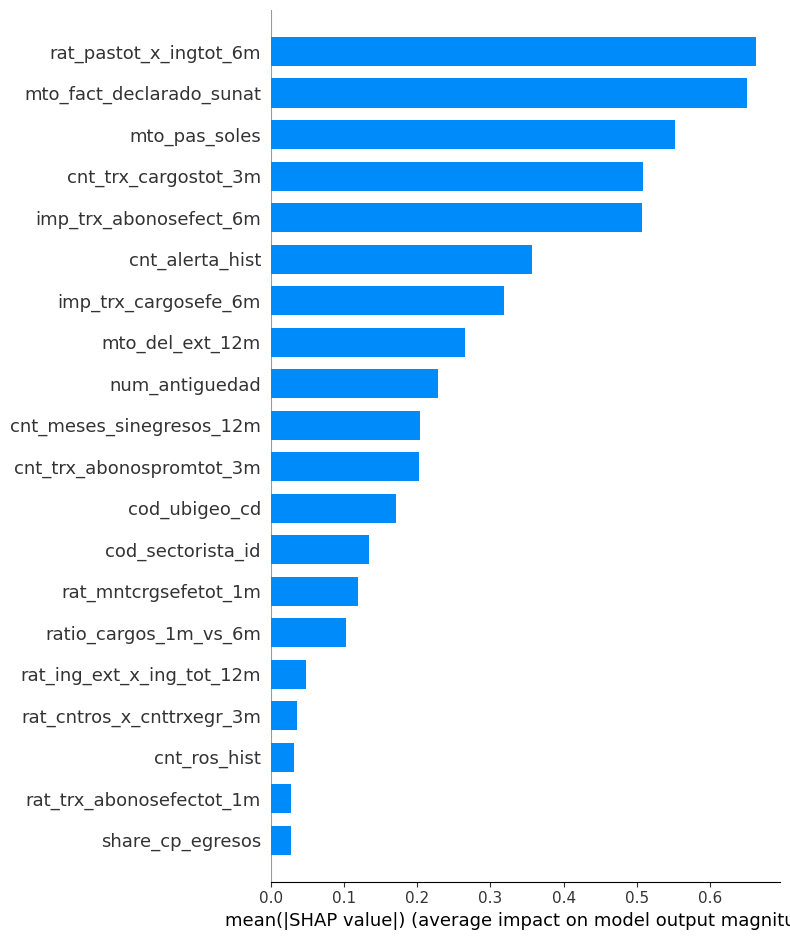

In [65]:
import shap
import pandas as pd
import numpy as np

# ===============================
# Dataset de referencia (ej: 202508)
# ===============================
df_ref = df_test[
    (df_test.cod_mes == 202508) 
    #&(df_test.tipo_alerta_n2 != '0')
].copy()

cols_excluir = ['key_value', 'cod_mes', 'cod_cli' , 'tipo_alerta_n2', 'target','trx_riesgo_cliente']
X_ref = df_ref.drop(columns=cols_excluir, errors='ignore')

# SHAP explainer (XGBoost)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_ref)

# Summary plot
shap.summary_plot(shap_values, X_ref, plot_type="bar")


In [66]:
variable_names = X_test.columns
# Calcula la magnitud promedio de los valores SHAP para cada variable
average_shap_values = np.abs(shap_values).mean(axis=0)

# Crea una lista de tuplas (variable, importancia, valor_absoluto)
variable_importance = [(variable_name, importance, abs_value) for variable_name, importance, abs_value in zip(variable_names, average_shap_values, shap_values.mean(axis=0))]

# Ordena la lista de importancia de mayor a menor
variable_importance.sort(key=lambda x: x[1], reverse=True)

# Obtén las variables más importantes junto con sus importancias y valores absolutos
variables_mas_importantes = [(variable[0], variable[1], variable[2]) for variable in variable_importance]

In [67]:
import csv

# Nombre del archivo CSV de salida
output_csv = 'importancia_variables.csv'

# Escribe los datos en el archivo CSV
with open(output_csv, 'w', newline='') as csvfile:
    
    # Define el escritor CSV
    csv_writer = csv.writer(csvfile)
    
    # Escribe el encabezado
    csv_writer.writerow(['Variable', 'Importancia', 'Valor Absoluto SHAP'])
    
    # Escribe los datos de cada variable
    for variable in variables_mas_importantes:
        csv_writer.writerow([variable[0], variable[1], variable[2]])


In [68]:
variables_mas_importantes

[('rat_pastot_x_ingtot_6m', np.float32(0.6620012), np.float32(-0.37739804)),
 ('mto_fact_declarado_sunat', np.float32(0.6503903), np.float32(-0.4796663)),
 ('mto_pas_soles', np.float32(0.5515882), np.float32(-0.35750833)),
 ('cnt_trx_cargostot_3m', np.float32(0.5080988), np.float32(-0.40517455)),
 ('imp_trx_abonosefect_6m', np.float32(0.50723076), np.float32(-0.44454706)),
 ('cnt_alerta_hist', np.float32(0.35607478), np.float32(-0.25740096)),
 ('imp_trx_cargosefe_6m', np.float32(0.31891456), np.float32(-0.2504466)),
 ('mto_del_ext_12m', np.float32(0.2653201), np.float32(-0.25013897)),
 ('num_antiguedad', np.float32(0.22907783), np.float32(-0.13734435)),
 ('cnt_meses_sinegresos_12m', np.float32(0.2037564), np.float32(-0.08155555)),
 ('cnt_trx_abonospromtot_3m',
  np.float32(0.20248437),
  np.float32(-0.014913195)),
 ('cod_ubigeo_cd', np.float32(0.17080948), np.float32(-0.108468585)),
 ('cod_sectorista_id', np.float32(0.13392287), np.float32(-0.08682539)),
 ('rat_mntcrgsefetot_1m', np.fl

In [ ]:

# ============================================================
# PRECISIÓN TOP20% y RECALL TOP20% — Train / Validation / Test
# Universo completo (todos los registros, no solo alertas)
# Ref: §13.4, §13.5, §13.6 DOCUMENTO_METODOLOGICO v2.1
# ============================================================

import pandas as pd
import numpy as np
import xgboost as xgb

PERIODOS_TRAIN = [202501, 202502, 202503, 202504, 202505, 202506, 202507]
PERIODOS_VAL   = [202508, 202509]
PERIODOS_TEST  = [202510, 202511, 202512, 202601, 202602, 202603, 202604]

COLS_EXCLUIR = ['key_value', 'cod_mes', 'cod_cli', 'tipo_alerta_n2',
                'trx_riesgo_cliente', 'target']

def _predecir(df_subset, modelo):
    X = df_subset.drop(columns=COLS_EXCLUIR, errors='ignore')
    dm = xgb.DMatrix(X, enable_categorical=True)
    return modelo.predict(dm)

def metricas_top_pct(df, prob_col, target_col, pct=0.20):
    """
    Calcula Precisión y Recall sobre el top `pct`% de registros por score.
    """
    df = df.sort_values(prob_col, ascending=False).reset_index(drop=True)
    k = max(1, int(np.ceil(len(df) * pct)))
    top = df.head(k)
    tp              = int(top[target_col].sum())
    total_positivos = int(df[target_col].sum())
    precision       = round(tp / k, 6) if k > 0 else 0.0
    recall          = round(tp / total_positivos, 6) if total_positivos > 0 else 0.0
    return {
        "n_total"        : len(df),
        "k_top20pct"     : k,
        "total_positivos": total_positivos,
        "tp_top20pct"    : tp,
        "precision_top20": round(precision * 100, 2),   # en %
        "recall_top20"   : round(recall    * 100, 2),   # en %
        "lift_top20"     : round(precision / (total_positivos / len(df)), 2)
                           if total_positivos > 0 else None,
    }

# ── Calcular por mes para cada conjunto ─────────────────────────────────────
def calcular_conjunto(df_base, periodos, nombre_conjunto):
    filas = []
    for mes in periodos:
        sub = df_base[df_base['cod_mes'] == float(mes)].copy()
        if sub.empty or sub['target'].sum() == 0:
            continue
        sub['prob'] = _predecir(sub, model)
        m = metricas_top_pct(sub, 'prob', 'target', pct=0.20)
        m['mes']       = mes
        m['conjunto']  = nombre_conjunto
        filas.append(m)
    return filas

filas_train = calcular_conjunto(df_train, PERIODOS_TRAIN, 'TRAIN')
filas_val   = calcular_conjunto(df_val,   PERIODOS_VAL,   'VALIDATION')
filas_test  = calcular_conjunto(df_test,  PERIODOS_TEST,  'TEST')

df_top20 = pd.DataFrame(filas_train + filas_val + filas_test)
df_top20 = df_top20[['conjunto','mes','n_total','total_positivos',
                      'k_top20pct','tp_top20pct',
                      'precision_top20','recall_top20','lift_top20']]

print("=" * 75)
print("PRECISIÓN TOP20% y RECALL TOP20% — universo completo")
print("=" * 75)
print(df_top20.to_string(index=False))

# ── Resumen por conjunto (promedio) ─────────────────────────────────────────
resumen = (
    df_top20.groupby('conjunto')[['precision_top20','recall_top20','lift_top20']]
    .mean()
    .round(2)
    .reindex(['TRAIN','VALIDATION','TEST'])
    .reset_index()
)
print()
print("RESUMEN PROMEDIO POR CONJUNTO:")
print(resumen.to_string(index=False))
print()
print("▶ Copiar a §13.4 (Train), §13.5 (Validation), §13.6 (Test) del documento v2.1")


In [17]:
#concilia con piloto

In [32]:
df_test_3.head()

,target,cnt_trx_cargostot_3m,mto_pas_soles,rat_pastot_x_ingtot_6m,cnt_trx_abonospromtot_3m,imp_trx_abonosefect_6m,num_antiguedad,imp_trx_cargosefe_6m,ratio_cargos_1m_vs_6m,cnt_meses_sinegresos_12m,...,share_cp_ingresos,mto_fact_declarado_sunat,cod_ubigeo_cd,cod_sectorista_id,key_value,cod_cli,cod_mes,tipo_alerta_n2,trx_riesgo_cliente,prob
0,0.0,0.0,0.00,0.021352,0.00,0.0,0.0,0.0,4580.909,12.0,...,0.0,3.0,3.0,3.0,3B020DB4DC631ED9192290632AD8627B2A9495500B2783...,21602930.0,202508.0,SIN_INFO,SIN_INFO,0.128483
1,0.0,0.0,0.00,0.021352,0.00,0.0,27.0,0.0,4580.909,12.0,...,0.0,3.0,3.0,2.0,2820FF155EBE1FF50F339495F0BDE21578CCE6AFD934D9...,7321045.0,202508.0,SIN_INFO,SIN_INFO,0.006566
2,0.0,212.0,25384.81,0.200318,32.00,0.0,2.0,900.0,92422.420,5.0,...,0.0,3.0,3.0,3.0,3194E86A626832BA5994B2318E2D0A0774892E5D769D76...,19639492.0,202508.0,SIN_INFO,SIN_INFO,0.165856
3,0.0,201.0,314865.94,0.882499,39.33,0.0,4.0,0.0,4580.909,0.0,...,0.0,1.0,3.0,3.0,6981440E76CCD482BE3D65197D2A85581859FA641A42B7...,18329162.0,202604.0,SIN_INFO,SIN_INFO,0.012824
4,0.0,15.0,652.00,0.224897,15.00,0.0,0.0,0.0,4580.909,11.0,...,0.0,3.0,3.0,3.0,ED6F89C0D3A75FF3F831AFBECCE36318F82E0E2C82DB41...,22031580.0,202603.0,SIN_INFO,SIN_INFO,0.167192


In [33]:
import pandas as pd

# ============================================================
# Conciliación df_test_3 (mes 202604) vs bases externas (piloto)
# Cruce inner por cod_cli (df_test_3) == codunico (csv)
# ============================================================

path_csv_1 = r"C:\Users\b46637\OneDrive - Interbank\PLAFT\PJ\Minorista\OLD\inferencia\desarrollo\df_6_razones_sospechosas_20260409 1.csv"
path_csv_2 = r"C:\Users\b46637\OneDrive - Interbank\PLAFT\PJ\Minorista\OLD\inferencia\desarrollo\df_6_razones_sospechosas_20260416.csv"

df_ext_1 = pd.read_csv(path_csv_1)
df_ext_2 = pd.read_csv(path_csv_2)

def normalizar_id(serie):
    # quita ".0" de floats y espacios, para poder cruzar ids numéricos como texto
    return (
        pd.to_numeric(serie, errors='coerce')
        .astype('Int64')
        .astype(str)
        .str.strip()
    )

df_test_202604 = df_test_3[df_test_3.cod_mes == 202604].copy()
df_test_202604['cod_cli'] = normalizar_id(df_test_202604['cod_cli'])

def conciliar(df_test_mes, df_ext, nombre_base):
    df_ext_ = df_ext.copy()
    df_ext_['codunico'] = normalizar_id(df_ext_['codunico'])

    merged = df_test_mes.merge(
        df_ext_[['codunico', 'score']],
        left_on='cod_cli',
        right_on='codunico',
        how='inner'
    )
    merged['base'] = nombre_base
    return merged[['cod_cli', 'cod_mes', 'target', 'prob', 'score', 'base']].rename(
        columns={'score': 'prob_piloto'}
    )

conciliado_1 = conciliar(df_test_202604, df_ext_1, 'df_6_razones_sospechosas_20260409 1')
conciliado_2 = conciliar(df_test_202604, df_ext_2, 'df_6_razones_sospechosas_20260409')

df_conciliado = pd.concat([conciliado_1, conciliado_2], ignore_index=True)
df_conciliado['diff_prob'] = df_conciliado['prob'] - df_conciliado['prob_piloto']

print(f"Coincidencias base 1: {len(conciliado_1)}")
print(f"Coincidencias base 2: {len(conciliado_2)}")

df_conciliado


Coincidencias base 1: 63
Coincidencias base 2: 32


,cod_cli,cod_mes,target,prob,prob_piloto,base,diff_prob
0,21905298,202604.0,0.0,0.980542,0.990190,df_6_razones_sospechosas_20260409 1,-0.009648
1,21736268,202604.0,0.0,0.991169,0.986006,df_6_razones_sospechosas_20260409 1,0.005163
2,21943372,202604.0,0.0,0.993966,0.990866,df_6_razones_sospechosas_20260409 1,0.003100
3,21977712,202604.0,0.0,0.994761,0.990966,df_6_razones_sospechosas_20260409 1,0.003795
4,21896636,202604.0,0.0,0.989835,0.984005,df_6_razones_sospechosas_20260409 1,0.005829
...,...,...,...,...,...,...,...
90,21975560,202604.0,0.0,0.993066,0.995165,df_6_razones_sospechosas_20260409,-0.002099
91,22063468,202604.0,0.0,0.996656,0.996018,df_6_razones_sospechosas_20260409,0.000638
92,22109646,202604.0,0.0,0.997101,0.996661,df_6_razones_sospechosas_20260409,0.000440
93,22054536,202604.0,0.0,0.992231,0.994452,df_6_razones_sospechosas_20260409,-0.002221


In [34]:
len(df_ext_1)

120

In [35]:
len(df_ext_2)

64

In [36]:
len(df_test_202604)

172505

In [37]:
print("cod_cli dtype original:", df_test_3['cod_cli'].dtype)
print(df_test_3['cod_cli'].head(10).tolist())

print("\ncodunico dtype original:", df_ext_1['codunico'].dtype)
print(df_ext_1['codunico'].head(10).tolist())

ids_test = set(normalizar_id(df_test_202604['cod_cli']))
ids_ext_1 = set(normalizar_id(df_ext_1['codunico']))
ids_ext_2 = set(normalizar_id(df_ext_2['codunico']))

no_match_1 = ids_ext_1 - ids_test
no_match_2 = ids_ext_2 - ids_test

print(f"\ncodunico base 1 sin match: {len(no_match_1)} de {len(ids_ext_1)}")
print(list(no_match_1)[:10])

print(f"\ncodunico base 2 sin match: {len(no_match_2)} de {len(ids_ext_2)}")
print(list(no_match_2)[:10])

# ¿Los ids "sin match" existen en otro mes de df_test, o en val? (df_train no tiene cod_cli)
ids_test_todos = set(normalizar_id(df_test['cod_cli']))
ids_val_todos  = set(normalizar_id(df_val['cod_cli']))

faltantes = no_match_1 | no_match_2
en_test_otro_mes = faltantes & ids_test_todos
en_val = faltantes & ids_val_todos
en_ningun_lado = faltantes - ids_test_todos - ids_val_todos

print(f"\nTotal ids sin match (unión base1+base2): {len(faltantes)}")
print(f"  presentes en df_test (otro mes): {len(en_test_otro_mes)}")
print(f"  presentes en df_val: {len(en_val)}")
print(f"  no existen en ninguna base cargada: {len(en_ningun_lado)}")


cod_cli dtype original: float64
[21602930.0, 7321045.0, 19639492.0, 18329162.0, 22031580.0, 21010838.0, 18466306.0, 20499696.0, 17190538.0, 20557890.0]

codunico dtype original: int64
[21927707, 21881108, 21932484, 21936243, 21971477, 21947688, 22024447, 22011612, 22054719, 21875153]

codunico base 1 sin match: 61 de 120
['19503433', '22087071', '19782535', '21917811', '21396713', '21994351', '21927707', '21933273', '21977847', '21936243']

codunico base 2 sin match: 35 de 64
['21973099', '22040445', '21882591', '21980449', '22104261', '22065925', '22190173', '22069441', '22109913', '22036611']

Total ids sin match (unión base1+base2): 96
  presentes en df_test (otro mes): 0
  presentes en df_val: 0
  no existen en ninguna base cargada: 96


In [38]:
df_ext_1_id = df_ext_1.copy()
df_ext_1_id['codunico'] = normalizar_id(df_ext_1_id['codunico'])
df_ext_1_id['base'] = 'df_6_razones_sospechosas_20260409 1'

df_ext_2_id = df_ext_2.copy()
df_ext_2_id['codunico'] = normalizar_id(df_ext_2_id['codunico'])
df_ext_2_id['base'] = 'df_6_razones_sospechosas_20260409'

df_faltantes_1 = df_ext_1_id[df_ext_1_id['codunico'].isin(no_match_1)]
df_faltantes_2 = df_ext_2_id[df_ext_2_id['codunico'].isin(no_match_2)]

df_ids_faltantes = pd.concat([df_faltantes_1, df_faltantes_2], ignore_index=True)[
    ['base', 'codunico', 'num_documento', 'codmes', 'score', 'orden']
].sort_values(['base', 'codunico'])

df_ids_faltantes


,base,codunico,num_documento,codmes,score,orden
95,df_6_razones_sospechosas_20260409,20053187,NaN,202604,0.993225,576
78,df_6_razones_sospechosas_20260409,21292833,NaN,202604,0.995093,503
85,df_6_razones_sospechosas_20260409,21542789,NaN,202604,0.994345,536
84,df_6_razones_sospechosas_20260409,21809989,NaN,202604,0.994379,534
89,df_6_razones_sospechosas_20260409,21882591,NaN,202604,0.993730,551
...,...,...,...,...,...,...
8,df_6_razones_sospechosas_20260409 1,22087071,NaN,202604,0.991783,733
49,df_6_razones_sospechosas_20260409 1,22088439,NaN,202604,0.985206,892
42,df_6_razones_sospechosas_20260409 1,22100457,NaN,202604,0.986146,873
21,df_6_razones_sospechosas_20260409 1,22114799,NaN,202604,0.989969,782


In [39]:
# Verificación: comparando con formato 10 dígitos con ceros a la izquierda
# (el resultado numérico es el mismo, el padding no cambia la igualdad)

def normalizar_id_padded(serie, ancho=10):
    return (
        pd.to_numeric(serie, errors='coerce')
        .astype('Int64')
        .astype(str)
        .str.zfill(ancho)
    )

ids_test_padded = set(normalizar_id_padded(df_test_202604['cod_cli']))
ids_ext_1_padded = set(normalizar_id_padded(df_ext_1['codunico']))
ids_ext_2_padded = set(normalizar_id_padded(df_ext_2['codunico']))

no_match_1_padded = ids_ext_1_padded - ids_test_padded
no_match_2_padded = ids_ext_2_padded - ids_test_padded

print(f"codunico base 1 sin match (formato 10 dígitos): {len(no_match_1_padded)} de {len(ids_ext_1_padded)}")
print(f"codunico base 2 sin match (formato 10 dígitos): {len(no_match_2_padded)} de {len(ids_ext_2_padded)}")
print("\n→ El padding con ceros no cambia el resultado: la comparación numérica ya era equivalente.")


codunico base 1 sin match (formato 10 dígitos): 61 de 120
codunico base 2 sin match (formato 10 dígitos): 35 de 64

→ El padding con ceros no cambia el resultado: la comparación numérica ya era equivalente.


In [40]:
import awswrangler as wr

parquet_path = 's3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/PLAFT/PJ/MINORISTA/DATA_INFERENCIA/data_pn_total_expandido_new_v2.parquet'

df_inferencia = wr.s3.read_parquet(path=parquet_path, boto3_session=session)

print(f"Shape: {df_inferencia.shape}")
print(f"\nColumnas: {df_inferencia.columns.tolist()}")


Shape: (1684424, 65)

Columnas: ['target', 'key_value', 'cod_cli', 'codmes_lag1', 'cod_mes', 'mto_pas_soles', 'imp_trx_abonosefect_6m', 'imp_trx_cargosefe_6m', 'avg_trx_cargostot_3m', 'max_trx_abonos_3m', 'cnt_trx_cargostot_3m', 'cnt_trx_abonospromtot_3m', 'rat_trx_abonosefectot_1m', 'rat_trx_abonosefectot_3m', 'rat_trx_abonosefectot_9m', 'rat_mntcrgsefetot_1m', 'num_edad_constitucion', 'num_antiguedad', 'desc_nivel_rsg_lsb_tot', 'cnt_meses_siningresos_12m', 'cnt_meses_sinegresos_12m', 'desc_provincia', 'desc_departamento', 'cod_ubigeo_cd', 'cod_sectorista_id', 'cod_ciiu_v4', 'flg_casos_hist', 'flg_vrcn_abonos_5m_1m', 'flg_vrcn_efe_cargos_5m_1m', 'cnt_ro_debajo_umbral', 'mto_fact_declarado_sunat', 'avg_cp_men_ing_12m', 'avg_cpmenegr_12m', 'max_mto_cpmening_12m', 'max_mto_cpegrmen_12m', 'flg_al_ext_12m', 'flg_del_ext_12m', 'cnt_trx_sinenv_alext_12m', 'cnt_trx_al_ext_1000_12m', 'mto_al_ext_12m', 'mto_del_ext_12m', 'flg_pep', 'cod_rsg_pep', 'flg_activo_pep', 'cnt_noticias', 'flg_ros_12m',

In [41]:
print(df_inferencia['cod_mes'].dtype)
print(sorted(df_inferencia['cod_mes'].unique()))


Int64
[np.int64(202501), np.int64(202502), np.int64(202503), np.int64(202504), np.int64(202505), np.int64(202506), np.int64(202507), np.int64(202508), np.int64(202509), np.int64(202510), np.int64(202511), np.int64(202512), np.int64(202601), np.int64(202602), np.int64(202603), np.int64(202604)]


In [42]:
import xgboost as xgb

# ============================================================
# Filtrar mes 04/2026 (202604) desde el parquet de inferencia
# y correr predict con el modelo ya cargado
# ============================================================

df_inf_202604 = df_inferencia[df_inferencia.cod_mes == 202604].copy()
print(f"Registros mes 202604: {len(df_inf_202604)}")

cols_excluir_inf = ['key_value', 'cod_cli', 'codmes_lag1', 'cod_mes',
                     'tipo_alerta_n2', 'trx_riesgo_cliente', 'target']
X_inf = df_inf_202604.drop(columns=cols_excluir_inf, errors='ignore')

# Alinear columnas al orden/nombres con los que se entrenó el modelo
X_inf = X_inf.reindex(columns=model.feature_names)

dinf = xgb.DMatrix(X_inf, enable_categorical=True)
df_inf_202604['prob'] = model.predict(dinf)

df_inf_202604[['key_value', 'cod_cli', 'cod_mes', 'prob']].head()


Registros mes 202604: 172505


,key_value,cod_cli,cod_mes,prob
174600,BE8F55650C2645322D5927060AB1E3F7D0C1C04AD143F2...,0021177767,202604,0.159011
174601,94891434745D9CEBC00BBCB0961B1BF2EADEB4DDE6C3C7...,0018245247,202604,0.050120
174602,15F0954CDE12201B2D1423A65C27FF95E8C5B3A8F087FA...,0020872103,202604,0.113093
174603,F94FD7BE09D13724DC6B0E64E289BDA4AF0DC028847C5E...,0021424893,202604,0.946854
174607,C4CED63F016FF22E97BDB3AF4178A112881B08A7231C32...,0018298046,202604,0.717317


In [43]:
# ============================================================
# Cruce inner por cliente contra las bases piloto (score)
# ============================================================

df_inf_202604['cod_cli_norm'] = normalizar_id(df_inf_202604['cod_cli'])

def conciliar_inferencia(df_inf, df_ext, nombre_base):
    df_ext_ = df_ext.copy()
    df_ext_['codunico'] = normalizar_id(df_ext_['codunico'])

    merged = df_inf.merge(
        df_ext_[['codunico', 'score']],
        left_on='cod_cli_norm',
        right_on='codunico',
        how='inner'
    )
    merged['base'] = nombre_base
    return merged[['cod_cli', 'cod_mes', 'prob', 'score', 'base']].rename(
        columns={'score': 'prob_piloto'}
    )

conciliado_inf_1 = conciliar_inferencia(df_inf_202604, df_ext_1, 'df_6_razones_sospechosas_20260409 1')
conciliado_inf_2 = conciliar_inferencia(df_inf_202604, df_ext_2, 'df_6_razones_sospechosas_20260409')

df_conciliado_inf = pd.concat([conciliado_inf_1, conciliado_inf_2], ignore_index=True)
df_conciliado_inf['diff_prob'] = df_conciliado_inf['prob'] - df_conciliado_inf['prob_piloto']

print(f"Coincidencias base 1: {len(conciliado_inf_1)} de {len(df_ext_1)}")
print(f"Coincidencias base 2: {len(conciliado_inf_2)} de {len(df_ext_2)}")

df_conciliado_inf


Coincidencias base 1: 120 de 120
Coincidencias base 2: 64 de 64


,cod_cli,cod_mes,prob,prob_piloto,base,diff_prob
0,0022019634,202604,0.356221,0.987842,df_6_razones_sospechosas_20260409 1,-0.631621
1,0022020085,202604,0.980361,0.985621,df_6_razones_sospechosas_20260409 1,-0.005260
2,0022075591,202604,0.968376,0.990449,df_6_razones_sospechosas_20260409 1,-0.022073
3,0021933273,202604,0.990602,0.984897,df_6_razones_sospechosas_20260409 1,0.005705
4,0022087071,202604,0.991136,0.991783,df_6_razones_sospechosas_20260409 1,-0.000647
...,...,...,...,...,...,...
179,0022100843,202604,0.998879,0.995144,df_6_razones_sospechosas_20260409,0.003735
180,0021969602,202604,0.995637,0.994969,df_6_razones_sospechosas_20260409,0.000668
181,0021809989,202604,0.995286,0.994379,df_6_razones_sospechosas_20260409,0.000907
182,0022113091,202604,0.996662,0.996402,df_6_razones_sospechosas_20260409,0.000260


In [57]:
# ============================================================
# Piloto original vs df_inf_202604 completo
# ============================================================

# El nuevo ranking considera todos los clientes de df_inf_202604,
# sin excluir por tipo_alerta_n2.
df_modelo_ranking = df_inf_202604.copy()

# Nuevo orden: 1 = probabilidad mas alta de todo df_inf_202604.
df_modelo_ranking['rank_modelo'] = (
    df_modelo_ranking['prob']
    .rank(ascending=False, method='first')
    .astype(int)
)

n_universo = len(df_modelo_ranking)
n_piloto = len(df_ext_1) + len(df_ext_2)


def comparar_piloto_con_modelo(df_ext, nombre_base):
    df_ext_ = df_ext.copy()
    df_ext_['codunico'] = normalizar_id(df_ext_['codunico'])

    # left merge conserva todos los clientes enviados en el piloto.
    comp = df_ext_[['codunico', 'orden', 'score']].merge(
        df_modelo_ranking[
            ['cod_cli_norm', 'cod_cli', 'prob', 'rank_modelo', 'tipo_alerta_n2']
        ],
        left_on='codunico',
        right_on='cod_cli_norm',
        how='left'
    )

    return comp[
        [
            'codunico', 'cod_cli', 'orden', 'score', 'prob',
            'rank_modelo', 'tipo_alerta_n2'
        ]
    ].rename(
        columns={
            'codunico': 'cod_cli_piloto',
            'cod_cli': 'cod_cli_modelo',
            'orden': 'orden_piloto_original',
            'score': 'prob_piloto'
        }
    ).assign(base=nombre_base)


comp_1 = comparar_piloto_con_modelo(
    df_ext_1,
    'df_6_razones_sospechosas_20260409 1'
)
comp_2 = comparar_piloto_con_modelo(
    df_ext_2,
    'df_6_razones_sospechosas_20260416'
)
df_comparacion_orden = pd.concat([comp_1, comp_2], ignore_index=True)

# Ranking piloto consecutivo, respetando el orden original del piloto.
df_comparacion_orden['rank_piloto'] = (
    df_comparacion_orden['orden_piloto_original']
    .rank(ascending=True, method='first')
    .astype(int)
)

df_comparacion_orden['estado_cruce'] = np.where(
    df_comparacion_orden['rank_modelo'].notna(),
    'Incluido en ranking completo',
    'No encontrado en df_inf_202604'
)

df_comparacion_orden['dif_prob'] = (
    df_comparacion_orden['prob'] - df_comparacion_orden['prob_piloto']
)
df_comparacion_orden['dif_orden'] = (
    df_comparacion_orden['rank_modelo'] - df_comparacion_orden['rank_piloto']
)

print(f"Universo completo de df_inf_202604: {n_universo}")
print(f"Clientes enviados en el piloto original: {n_piloto}")
print(df_comparacion_orden['estado_cruce'].value_counts(dropna=False))

df_comparacion_orden.sort_values('rank_piloto')

Universo completo de df_inf_202604: 172505
Clientes enviados en el piloto original: 184
estado_cruce
Incluido en ranking completo    184
Name: count, dtype: int64


,cod_cli_piloto,cod_cli_modelo,orden_piloto_original,prob_piloto,prob,rank_modelo,tipo_alerta_n2,base,rank_piloto,estado_cruce,dif_prob,dif_orden
120,21948529,0021948529,398,0.997276,0.996114,95,SIN_INFO,df_6_razones_sospechosas_20260416,1,Incluido en ranking completo,-0.001162,94
121,22190173,0022190173,418,0.997007,0.995481,135,SIN_INFO,df_6_razones_sospechosas_20260416,2,Incluido en ranking completo,-0.001526,133
122,22118647,0022118647,429,0.996746,0.997100,34,SIN_INFO,df_6_razones_sospechosas_20260416,3,Incluido en ranking completo,0.000354,31
123,22109646,0022109646,434,0.996661,0.997101,33,SIN_INFO,df_6_razones_sospechosas_20260416,4,Incluido en ranking completo,0.000440,29
124,21985478,0021985478,436,0.996643,0.994885,179,SIN_INFO,df_6_razones_sospechosas_20260416,5,Incluido en ranking completo,-0.001757,174
125,22066220,0022066220,437,0.996615,0.996892,48,SIN_INFO,df_6_razones_sospechosas_20260416,6,Incluido en ranking completo,0.000277,42
126,22104261,0022104261,439,0.996533,0.997185,31,SIN_INFO,df_6_razones_sospechosas_20260416,7,Incluido en ranking completo,0.000652,24
127,21931341,0021931341,441,0.996446,0.994504,209,SIN_INFO,df_6_razones_sospechosas_20260416,8,Incluido en ranking completo,-0.001942,201
128,22113091,0022113091,445,0.996402,0.996662,63,SIN_INFO,df_6_razones_sospechosas_20260416,9,Incluido en ranking completo,0.000260,54
129,21454964,0021454964,450,0.996226,0.995840,105,SEMI AUTOMATICA,df_6_razones_sospechosas_20260416,10,Incluido en ranking completo,-0.000386,95


In [58]:
# ============================================================
# Validacion de similitud: piloto original vs nuevo modelo
# ============================================================

# Se validan solo clientes con cruce exitoso y ambas probabilidades disponibles.
df_validacion_similitud = df_comparacion_orden.dropna(
    subset=['prob_piloto', 'prob', 'rank_piloto', 'rank_modelo']
).copy()

n_validacion = len(df_validacion_similitud)
delta_prob = (
    df_validacion_similitud['prob']
    - df_validacion_similitud['prob_piloto']
)
delta_rank = (
    df_validacion_similitud['rank_modelo']
    - df_validacion_similitud['rank_piloto']
)

metricas_similitud = pd.DataFrame({
    'metrica': [
        'Clientes evaluados',
        'Correlacion Pearson de probabilidades',
        'Correlacion Spearman de probabilidades',
        'MAE absoluto de probabilidad',
        'RMSE de probabilidad',
        'Clientes con diferencia de probabilidad <= 0.005',
        'Clientes con diferencia de probabilidad <= 0.010',
        'Mediana de diferencia absoluta de ranking',
        'Clientes con diferencia absoluta de ranking <= 10',
        'Clientes con diferencia absoluta de ranking <= 25',
        'Clientes con diferencia absoluta de ranking <= 50',
    ],
    'valor': [
        n_validacion,
        df_validacion_similitud['prob_piloto'].corr(
            df_validacion_similitud['prob'], method='pearson'
        ),
        df_validacion_similitud['prob_piloto'].corr(
            df_validacion_similitud['prob'], method='spearman'
        ),
        delta_prob.abs().mean(),
        np.sqrt((delta_prob ** 2).mean()),
        (delta_prob.abs() <= 0.005).sum(),
        (delta_prob.abs() <= 0.010).sum(),
        delta_rank.abs().median(),
        (delta_rank.abs() <= 10).sum(),
        (delta_rank.abs() <= 25).sum(),
        (delta_rank.abs() <= 50).sum(),
    ]
})

# Coincidencia de los principales clientes del piloto en el ranking actual.
filas_top_k = []
for k in [10, 20, 50, 100]:
    top_piloto = set(
        df_validacion_similitud.loc[
            df_validacion_similitud['rank_piloto'] <= k,
            'cod_cli_piloto'
        ]
    )
    top_modelo = set(
        df_validacion_similitud.loc[
            df_validacion_similitud['rank_modelo'] <= k,
            'cod_cli_piloto'
        ]
    )
    interseccion = len(top_piloto & top_modelo)
    filas_top_k.append({
        'K': k,
        'clientes_top_k_piloto': len(top_piloto),
        'clientes_top_k_modelo': len(top_modelo),
        'coincidencias': interseccion,
        'recall_top_k_piloto': interseccion / len(top_piloto)
        if top_piloto else 0.0,
    })

df_top_k_similitud = pd.DataFrame(filas_top_k)

print('METRICAS DE SIMILITUD')
display(metricas_similitud)
print('COINCIDENCIA DE CLIENTES EN TOP-K')
display(df_top_k_similitud)

# Clientes con mayor cambio de posicion para revisar excepciones.
df_mayores_cambios = (
    df_validacion_similitud.assign(
        diferencia_abs_rank=delta_rank.abs(),
        diferencia_abs_prob=delta_prob.abs()
    )
    .sort_values(
        ['diferencia_abs_rank', 'diferencia_abs_prob'],
        ascending=False
    )
    [[
        'cod_cli_piloto', 'rank_piloto', 'prob_piloto',
        'rank_modelo', 'prob', 'dif_orden', 'dif_prob',
        'tipo_alerta_n2'
    ]]
)

df_mayores_cambios.head(20)

METRICAS DE SIMILITUD


,metrica,valor
0,Clientes evaluados,184.000000
1,Correlacion Pearson de probabilidades,0.103033
2,Correlacion Spearman de probabilidades,0.575129
3,MAE absoluto de probabilidad,0.031717
4,RMSE de probabilidad,0.124019
5,Clientes con diferencia de probabilidad <= 0.005,115.000000
6,Clientes con diferencia de probabilidad <= 0.010,151.000000
7,Mediana de diferencia absoluta de ranking,289.500000
8,Clientes con diferencia absoluta de ranking <= 10,3.000000
9,Clientes con diferencia absoluta de ranking <= 25,13.000000


COINCIDENCIA DE CLIENTES EN TOP-K


,K,clientes_top_k_piloto,clientes_top_k_modelo,coincidencias,recall_top_k_piloto
0,10,10,5,0,0.00
1,20,20,9,1,0.05
2,50,50,17,12,0.24
3,100,100,23,22,0.22


,cod_cli_piloto,rank_piloto,prob_piloto,rank_modelo,prob,dif_orden,dif_prob,tipo_alerta_n2
87,22100457,152,0.986146,43606,0.239077,43454,-0.747069,SIN_INFO
156,22040445,37,0.994661,41059,0.252419,41022,-0.742242,SIN_INFO
67,22019634,132,0.987842,27709,0.356221,27577,-0.631621,SIN_INFO
40,22044922,105,0.989304,26552,0.364029,26447,-0.625275,SIN_INFO
106,22042318,171,0.984665,23767,0.390422,23596,-0.594243,SIN_INFO
10,22090236,75,0.992238,22081,0.411647,22006,-0.580591,SIN_INFO
150,21292833,31,0.995093,13806,0.583673,13775,-0.411420,SIN_INFO
46,19782535,111,0.989067,4931,0.881525,4820,-0.107542,SIN_INFO
11,22063180,76,0.992206,4861,0.883592,4785,-0.108614,SIN_INFO
112,22111510,177,0.984276,4758,0.886659,4581,-0.097617,SIN_INFO


In [59]:
# ============================================================
# Similitud del orden relativo dentro de los 184 clientes piloto
# ============================================================

# Este ranking no mide la posicion frente a todo el universo.
# Mide si el nuevo modelo conserva el orden entre los mismos 184 clientes.
df_validacion_similitud['rank_modelo_dentro_piloto'] = (
    df_validacion_similitud['prob']
    .rank(ascending=False, method='first')
    .astype(int)
)

delta_rank_relativo = (
    df_validacion_similitud['rank_modelo_dentro_piloto']
    - df_validacion_similitud['rank_piloto']
)

metricas_orden_relativo = pd.DataFrame({
    'metrica': [
        'Correlacion Spearman del orden relativo',
        'Mediana de diferencia absoluta de orden relativo',
        'Clientes con diferencia relativa <= 10 posiciones',
        'Clientes con diferencia relativa <= 25 posiciones',
        'Clientes con diferencia relativa <= 50 posiciones',
    ],
    'valor': [
        df_validacion_similitud['rank_piloto'].corr(
            df_validacion_similitud['rank_modelo_dentro_piloto'],
            method='spearman'
        ),
        delta_rank_relativo.abs().median(),
        (delta_rank_relativo.abs() <= 10).sum(),
        (delta_rank_relativo.abs() <= 25).sum(),
        (delta_rank_relativo.abs() <= 50).sum(),
    ]
})

filas_top_k_relativo = []
for k in [10, 20, 50, 100]:
    top_piloto = set(
        df_validacion_similitud.loc[
            df_validacion_similitud['rank_piloto'] <= k,
            'cod_cli_piloto'
        ]
    )
    top_modelo_relativo = set(
        df_validacion_similitud.loc[
            df_validacion_similitud['rank_modelo_dentro_piloto'] <= k,
            'cod_cli_piloto'
        ]
    )
    interseccion = len(top_piloto & top_modelo_relativo)
    filas_top_k_relativo.append({
        'K': k,
        'coincidencias': interseccion,
        'recall_top_k_relativo': interseccion / len(top_piloto)
        if top_piloto else 0.0,
    })

df_top_k_relativo = pd.DataFrame(filas_top_k_relativo)

print('METRICAS DEL ORDEN RELATIVO ENTRE LOS 184 CLIENTES')
display(metricas_orden_relativo)
print('COINCIDENCIA TOP-K DENTRO DE LOS 184 CLIENTES')
display(df_top_k_relativo)

df_validacion_similitud[
    [
        'cod_cli_piloto', 'rank_piloto', 'prob_piloto',
        'rank_modelo_dentro_piloto', 'prob', 'dif_prob'
    ]
].sort_values('rank_piloto')

METRICAS DEL ORDEN RELATIVO ENTRE LOS 184 CLIENTES


,metrica,valor
0,Correlacion Spearman del orden relativo,0.575129
1,Mediana de diferencia absoluta de orden relativo,31.000000
2,Clientes con diferencia relativa <= 10 posiciones,37.000000
3,Clientes con diferencia relativa <= 25 posiciones,79.000000
4,Clientes con diferencia relativa <= 50 posiciones,133.000000


COINCIDENCIA TOP-K DENTRO DE LOS 184 CLIENTES


,K,coincidencias,recall_top_k_relativo
0,10,1,0.10
1,20,9,0.45
2,50,31,0.62
3,100,75,0.75


,cod_cli_piloto,rank_piloto,prob_piloto,rank_modelo_dentro_piloto,prob,dif_prob
120,21948529,1,0.997276,23,0.996114,-0.001162
121,22190173,2,0.997007,38,0.995481,-0.001526
122,22118647,3,0.996746,13,0.997100,0.000354
123,22109646,4,0.996661,12,0.997101,0.000440
124,21985478,5,0.996643,47,0.994885,-0.001757
125,22066220,6,0.996615,16,0.996892,0.000277
126,22104261,7,0.996533,10,0.997185,0.000652
127,21931341,8,0.996446,56,0.994504,-0.001942
128,22113091,9,0.996402,19,0.996662,0.000260
129,21454964,10,0.996226,25,0.995840,-0.000386


In [60]:
# ============================================================
# Casos fuera con punto de corte
# ============================================================

PUNTO_CORTE_ACTUAL = 0.989226

# Universo del piloto cruzado contra el nuevo modelo.
fuera_piloto = df_comparacion_orden[
    df_comparacion_orden['prob'] < PUNTO_CORTE_ACTUAL
].copy()

# Universo completo de df_inf_202604.
fuera_universo = df_inf_202604[
    df_inf_202604['prob'] < PUNTO_CORTE_ACTUAL
].copy()

print(f"Punto de corte: {PUNTO_CORTE_ACTUAL:.6f}")
print(
    f"Fuera dentro del piloto: {len(fuera_piloto)} de "
    f"{len(df_comparacion_orden)} "
    f"({len(fuera_piloto) / len(df_comparacion_orden):.1%})"
)
print(
    f"Fuera en df_inf_202604 completo: {len(fuera_universo)} de "
    f"{len(df_inf_202604)} "
    f"({len(fuera_universo) / len(df_inf_202604):.1%})"
)

fuera_piloto[
    [
        'cod_cli_piloto', 'rank_piloto', 'prob_piloto',
        'prob', 'rank_modelo', 'tipo_alerta_n2'
    ]
].sort_values('prob')

Punto de corte: 0.989226
Fuera dentro del piloto: 68 de 184 (37.0%)
Fuera en df_inf_202604 completo: 171910 de 172505 (99.7%)


,cod_cli_piloto,rank_piloto,prob_piloto,prob,rank_modelo,tipo_alerta_n2
87,22100457,152,0.986146,0.239077,43606,SIN_INFO
156,22040445,37,0.994661,0.252419,41059,SIN_INFO
67,22019634,132,0.987842,0.356221,27709,SIN_INFO
40,22044922,105,0.989304,0.364029,26552,SIN_INFO
106,22042318,171,0.984665,0.390422,23767,SIN_INFO
10,22090236,75,0.992238,0.411647,22081,SIN_INFO
150,21292833,31,0.995093,0.583673,13806,SIN_INFO
46,19782535,111,0.989067,0.881525,4931,SIN_INFO
11,22063180,76,0.992206,0.883592,4861,SIN_INFO
112,22111510,177,0.984276,0.886659,4758,SIN_INFO


In [45]:
print(df_inf_202604['tipo_alerta_n2'].value_counts(dropna=False))


tipo_alerta_n2
SIN_INFO           171837
AUTOMATICA            502
MANUAL                 94
SEMI AUTOMATICA        72
Name: count, dtype: Int64


In [46]:
# ============================================================
# Repetir la comparación de orden, pero rankeando SOLO dentro
# del subconjunto de "alertas nuevas" (mismo criterio usado en
# el resto del notebook: tipo_alerta_n2 != 'SIN_INFO'),
# que es el candidate pool real del que salió el piloto.
# ============================================================

df_candidatos = df_inf_202604[df_inf_202604['tipo_alerta_n2'] != 'SIN_INFO'].copy()
df_candidatos['rank_modelo_candidatos'] = df_candidatos['prob'].rank(ascending=False, method='min').astype(int)
n_candidatos = len(df_candidatos)
print(f"Candidatos (tipo_alerta_n2 != 'SIN_INFO'): {n_candidatos}")

def comparar_orden_candidatos(df_ext, nombre_base):
    df_ext_ = df_ext.copy()
    df_ext_['codunico'] = normalizar_id(df_ext_['codunico'])

    comp = df_candidatos.merge(
        df_ext_[['codunico', 'orden', 'score']],
        left_on='cod_cli_norm',
        right_on='codunico',
        how='inner'
    )
    return comp[['cod_cli', 'orden', 'rank_modelo_candidatos', 'prob', 'score']].rename(
        columns={'orden': 'orden_piloto', 'score': 'prob_piloto'}
    ).assign(base=nombre_base)

comp_c1 = comparar_orden_candidatos(df_ext_1, 'df_6_razones_sospechosas_20260409 1')
comp_c2 = comparar_orden_candidatos(df_ext_2, 'df_6_razones_sospechosas_20260409')
df_comparacion_candidatos = pd.concat([comp_c1, comp_c2], ignore_index=True)

n_piloto_base1, n_piloto_base2 = len(df_ext_1), len(df_ext_2)

for nombre, grupo, n_piloto_base in [
    ('df_6_razones_sospechosas_20260409 1', comp_c1, n_piloto_base1),
    ('df_6_razones_sospechosas_20260409', comp_c2, n_piloto_base2),
]:
    corr = grupo[['orden_piloto', 'rank_modelo_candidatos']].corr(method='spearman').iloc[0, 1]
    en_top = (grupo['rank_modelo_candidatos'] <= n_piloto_base).sum()
    print(f"\n{nombre}: {len(grupo)} de {n_piloto_base} coinciden con candidatos")
    print(f"  Correlación de Spearman (orden piloto vs rank modelo en candidatos) = {corr:.3f}")
    print(f"  En el propio top-{n_piloto_base} del modelo (dentro de candidatos): {en_top} ({en_top/len(grupo):.1%})")

df_comparacion_candidatos.sort_values('orden_piloto')


Candidatos (tipo_alerta_n2 != 'SIN_INFO'): 668

df_6_razones_sospechosas_20260409 1: 10 de 120 coinciden con candidatos
  Correlación de Spearman (orden piloto vs rank modelo en candidatos) = 0.091
  En el propio top-120 del modelo (dentro de candidatos): 9 (90.0%)

df_6_razones_sospechosas_20260409: 7 de 64 coinciden con candidatos
  Correlación de Spearman (orden piloto vs rank modelo en candidatos) = 0.821
  En el propio top-64 del modelo (dentro de candidatos): 6 (85.7%)


,cod_cli,orden_piloto,rank_modelo_candidatos,prob,prob_piloto,base
15,0021454964,450,36,0.995840,0.996226,df_6_razones_sospechosas_20260409
10,0021885882,454,41,0.995498,0.996189,df_6_razones_sospechosas_20260409
16,0021973119,480,19,0.996902,0.995691,df_6_razones_sospechosas_20260409
13,0021788462,513,45,0.995169,0.994765,df_6_razones_sospechosas_20260409
12,0021542789,536,43,0.995353,0.994345,df_6_razones_sospechosas_20260409
11,0021882591,551,75,0.993366,0.993730,df_6_razones_sospechosas_20260409
14,0022091878,568,51,0.994589,0.993390,df_6_razones_sospechosas_20260409
5,0021881108,694,95,0.991689,0.992926,df_6_razones_sospechosas_20260409 1
9,0021932484,695,94,0.991829,0.992924,df_6_razones_sospechosas_20260409 1
0,0022024447,703,50,0.994734,0.992667,df_6_razones_sospechosas_20260409 1


In [47]:
# ============================================================
# Cruce simple: prob (modelo actual) vs prob_piloto, cliente por cliente
# ============================================================

pd.set_option('display.max_rows', None)

df_prob_vs_prob = df_conciliado_inf[['base', 'cod_cli', 'prob', 'prob_piloto', 'diff_prob']].sort_values(
    ['base', 'prob_piloto'], ascending=[True, False]
).reset_index(drop=True)

df_prob_vs_prob


,base,cod_cli,prob,prob_piloto,diff_prob
0,df_6_razones_sospechosas_20260409,0021948529,0.996114,0.997276,-0.001162
1,df_6_razones_sospechosas_20260409,0022190173,0.995481,0.997007,-0.001526
2,df_6_razones_sospechosas_20260409,0022118647,0.997100,0.996746,0.000354
3,df_6_razones_sospechosas_20260409,0022109646,0.997101,0.996661,0.000440
4,df_6_razones_sospechosas_20260409,0021985478,0.994885,0.996643,-0.001757
5,df_6_razones_sospechosas_20260409,0022066220,0.996892,0.996615,0.000277
6,df_6_razones_sospechosas_20260409,0022104261,0.997185,0.996533,0.000652
7,df_6_razones_sospechosas_20260409,0021931341,0.994504,0.996446,-0.001942
8,df_6_razones_sospechosas_20260409,0022113091,0.996662,0.996402,0.000260
9,df_6_razones_sospechosas_20260409,0021454964,0.995840,0.996226,-0.000386


In [48]:
n_menor_96 = (df_prob_vs_prob['prob'] < 0.96).sum()
print(f"Clientes con prob (modelo actual) < 0.96: {n_menor_96} de {len(df_prob_vs_prob)}")

df_prob_vs_prob[df_prob_vs_prob['prob'] < 0.96]


Clientes con prob (modelo actual) < 0.96: 19 de 184


,base,cod_cli,prob,prob_piloto,diff_prob
30,df_6_razones_sospechosas_20260409,0021292833,0.583673,0.995093,-0.411420
36,df_6_razones_sospechosas_20260409,0022040445,0.252419,0.994661,-0.742242
74,df_6_razones_sospechosas_20260409 1,0022090236,0.411647,0.992238,-0.580591
75,df_6_razones_sospechosas_20260409 1,0022063180,0.883592,0.992206,-0.108614
104,df_6_razones_sospechosas_20260409 1,0022044922,0.364029,0.989304,-0.625275
110,df_6_razones_sospechosas_20260409 1,0019782535,0.881525,0.989067,-0.107542
124,df_6_razones_sospechosas_20260409 1,0017269518,0.951179,0.988275,-0.037096
125,df_6_razones_sospechosas_20260409 1,0021977847,0.940706,0.988263,-0.047557
131,df_6_razones_sospechosas_20260409 1,0022019634,0.356221,0.987842,-0.631621
140,df_6_razones_sospechosas_20260409 1,0017356462,0.922149,0.987177,-0.065028


In [56]:
# ============================================================
# Tabla final: piloto original vs nuevo orden del modelo
# ============================================================

df_orden_lado_a_lado = df_comparacion_orden[
    [
        'base',
        'cod_cli_piloto',
        'cod_cli_modelo',
        'rank_piloto',
        'orden_piloto_original',
        'prob_piloto',
        'rank_modelo',
        'prob',
        'dif_prob',
        'dif_orden',
        'tipo_alerta_n2',
        'estado_cruce',
    ]
].sort_values(
    ['rank_piloto']
).reset_index(drop=True)

df_orden_lado_a_lado

,base,cod_cli_piloto,cod_cli_modelo,rank_piloto,orden_piloto_original,prob_piloto,rank_modelo,prob,dif_prob,dif_orden,tipo_alerta_n2,estado_cruce
0,df_6_razones_sospechosas_20260416,21948529,0021948529,1,398,0.997276,62.0,0.996114,-0.001162,61.0,SIN_INFO,Incluido en ranking nuevo
1,df_6_razones_sospechosas_20260416,22190173,0022190173,2,418,0.997007,94.0,0.995481,-0.001526,92.0,SIN_INFO,Incluido en ranking nuevo
2,df_6_razones_sospechosas_20260416,22118647,0022118647,3,429,0.996746,22.0,0.997100,0.000354,19.0,SIN_INFO,Incluido en ranking nuevo
3,df_6_razones_sospechosas_20260416,22109646,0022109646,4,434,0.996661,21.0,0.997101,0.000440,17.0,SIN_INFO,Incluido en ranking nuevo
4,df_6_razones_sospechosas_20260416,21985478,0021985478,5,436,0.996643,132.0,0.994885,-0.001757,127.0,SIN_INFO,Incluido en ranking nuevo
5,df_6_razones_sospechosas_20260416,22066220,0022066220,6,437,0.996615,29.0,0.996892,0.000277,23.0,SIN_INFO,Incluido en ranking nuevo
6,df_6_razones_sospechosas_20260416,22104261,0022104261,7,439,0.996533,19.0,0.997185,0.000652,12.0,SIN_INFO,Incluido en ranking nuevo
7,df_6_razones_sospechosas_20260416,21931341,0021931341,8,441,0.996446,157.0,0.994504,-0.001942,149.0,SIN_INFO,Incluido en ranking nuevo
8,df_6_razones_sospechosas_20260416,22113091,0022113091,9,445,0.996402,40.0,0.996662,0.000260,31.0,SIN_INFO,Incluido en ranking nuevo
9,df_6_razones_sospechosas_20260416,21454964,<NA>,10,450,0.996226,NaN,NaN,NaN,NaN,SEMI AUTOMATICA,Excluido por alerta anterior


In [50]:
df_ext_1.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_nueva_alerta,score,orden,variable1,variable2,variable3,razon_sospechosa
0,202604,NaN,21927707,plaft_pj_minorista,20260409,P1,0,0.992935,693,SIN_INFO,NaN,NaN,"Cargos en efectivo muy elevados (S/1,059,300) ..."
1,202604,NaN,21881108,plaft_pj_minorista,20260409,P1,0,0.992926,694,SIN_INFO,NaN,NaN,"Cargos en efectivo muy elevados (S/2,121,674) ..."
2,202604,NaN,21932484,plaft_pj_minorista,20260409,P1,0,0.992924,695,SIN_INFO,NaN,NaN,"Cargos en efectivo muy elevados (S/765,475) co..."
3,202604,NaN,21936243,plaft_pj_minorista,20260409,P1,0,0.992869,696,SIN_INFO,NaN,NaN,Casi el 100% de abonos son en efectivo (ratio ...
4,202604,NaN,21971477,plaft_pj_minorista,20260409,P1,0,0.992842,697,SIN_INFO,NaN,NaN,"Cargos en efectivo muy elevados (S/1,244,722) ..."
